In [1]:
from google.colab import files


uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')



Saving archive (1).zip to archive (1).zip
User uploaded file "archive (1).zip" with length 3848 bytes


In [2]:
import zipfile
import os
import pandas as pd
zip_file_name = 'archive (1).zip'
extraction_path = 'extracted_data'
os.makedirs(extraction_path, exist_ok=True)
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_name}' unzipped to '{extraction_path}'")


'archive (1).zip' unzipped to 'extracted_data'


In [3]:

csv_file_path = os.path.join(extraction_path, 'car data.csv')
df = pd.read_csv(csv_file_path)

print(f"Data loaded from '{csv_file_path}' into a pandas DataFrame.")
display(df.head())

Data loaded from 'extracted_data/car data.csv' into a pandas DataFrame.


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print(f"The DataFrame 'df' has {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.info())

The DataFrame 'df' has 301 rows and 9 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


None

In [6]:

missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

print("Missing values in each column:")
display(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("No missing values found in the dataset.")

Missing values in each column:


,Missing Count,Missing Percentage


No missing values found in the dataset.


In [7]:
# Display descriptive statistics for numerical columns
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
# Get list of categorical columns (object type)
categorical_cols = df.select_dtypes(include='object').columns

print("Unique values and their counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(df[col].value_counts())

Unique values and their counts for categorical columns:

Column: Car_Name


,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1



Column: Fuel_Type


,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2



Column: Selling_type


,count
Selling_type,
Dealer,195
Individual,106



Column: Transmission


,count
Transmission,
Manual,261
Automatic,40


In [9]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows.")
    # Remove duplicate rows
    df_cleaned = df.drop_duplicates().copy()
    print(f"Removed {duplicate_rows} duplicate rows. New DataFrame shape: {df_cleaned.shape}")
    df = df_cleaned
else:
    print("No duplicate rows found in the dataset.")

Found 2 duplicate rows.
Removed 2 duplicate rows. New DataFrame shape: (299, 9)


In [10]:
# Standardize column names (e.g., to lowercase and replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(' ', '_')

print("Column names have been standardized:")
display(df.columns)

Column names have been standardized:


Index(['car_name', 'year', 'selling_price', 'present_price', 'driven_kms',
       'fuel_type', 'selling_type', 'transmission', 'owner'],
      dtype='object')

In [11]:
import datetime

# Calculate current year
current_year = datetime.date.today().year

# Create 'car_age' feature
df['car_age'] = current_year - df['year']

print("New feature 'car_age' created:")
display(df[['year', 'car_age']].head())

New feature 'car_age' created:


,year,car_age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [ ]:
import pandas as pd

# Identify categorical columns for one-hot encoding (excluding 'car_name' due to high cardinality)
categorical_cols_to_encode = ['fuel_type', 'selling_type', 'transmission']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("Categorical features encoded:")
display(df.head())

Categorical features encoded:


,car_name,year,selling_price,present_price,driven_kms,owner,car_age,fuel_type_Diesel,fuel_type_Petrol,selling_type_Individual,transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,12,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,13,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,9,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,15,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,12,True,False,False,True


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Identify categorical columns for one-hot encoding (excluding 'car_name' due to high cardinality)
categorical_cols_to_encode = ['fuel_type', 'selling_type', 'transmission']

# Apply one-hot encoding
# Create a copy to avoid SettingWithCopyWarning if df was a slice
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols_to_encode, drop_first=True)

print("Categorical features encoded (before splitting):")
display(df_encoded.head())

# Define features (X) and target (y) from the encoded DataFrame
X = df_encoded.drop(['car_name', 'selling_price', 'year'], axis=1)
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Categorical features encoded (before splitting):


,car_name,year,selling_price,present_price,driven_kms,owner,car_age,fuel_type_Diesel,fuel_type_Petrol,selling_type_Individual,transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,12,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,13,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,9,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,15,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,12,True,False,False,True



Data split into training and testing sets:
X_train shape: (239, 8)
X_test shape: (60, 8)
y_train shape: (239,)
y_test shape: (60,)


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Calculate RMSE

print(f"R-squared (R2) score: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (R2) score: 0.52
Mean Absolute Error (MAE): 1.47
Mean Squared Error (MSE): 12.32
Root Mean Squared Error (RMSE): 3.51


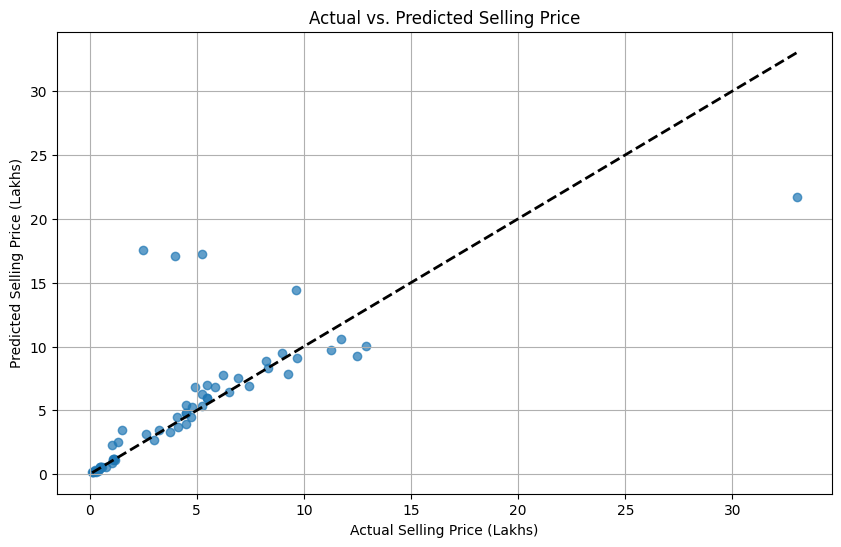

Sample of Actual vs. Predicted Selling Prices:


,Actual,Predicted
283,8.99,9.5021
267,8.35,8.2800
166,0.45,0.4424
9,7.45,6.9180
78,5.25,17.2575


In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Selling Price (Lakhs)')
plt.ylabel('Predicted Selling Price (Lakhs)')
plt.title('Actual vs. Predicted Selling Price')
plt.grid(True)
plt.show()

predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Sample of Actual vs. Predicted Selling Prices:")
display(predictions_df.head())

Feature Importances:


,Feature,Importance
0,present_price,0.904397
3,car_age,0.071972
1,driven_kms,0.013325
7,transmission_Manual,0.005996
6,selling_type_Individual,0.002313
4,fuel_type_Diesel,0.001313
5,fuel_type_Petrol,0.000678
2,owner,0.000006


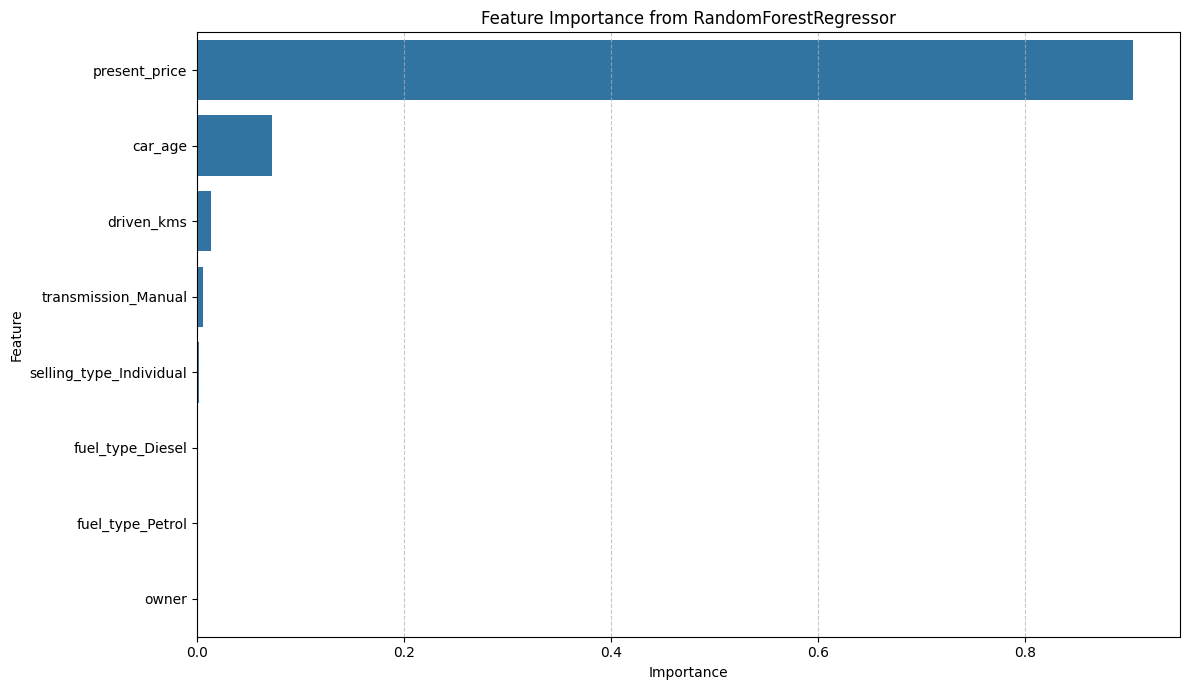

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from RandomForestRegressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

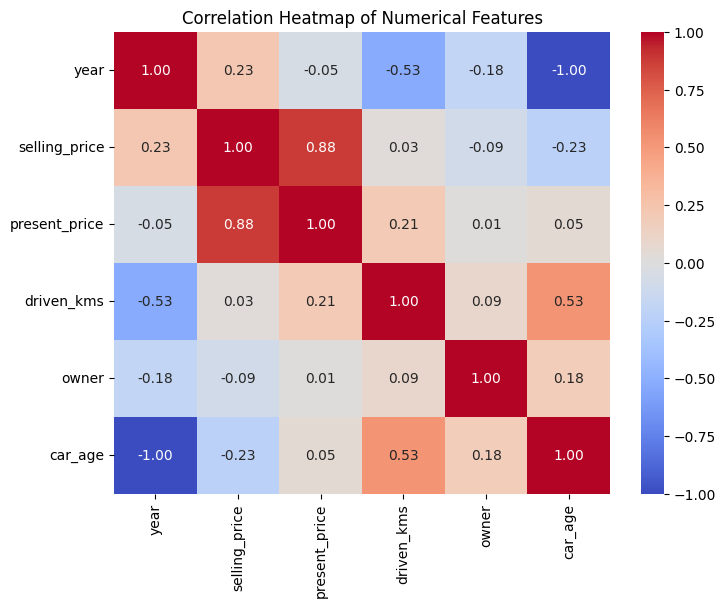

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(8, 6)) # Reduced figure size
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

This heatmap shows the correlation between the numerical features. Strong positive correlations (closer to 1) are shown in warmer colors, and strong negative correlations (closer to -1) in cooler colors. This helps identify features that move together or in opposite directions.

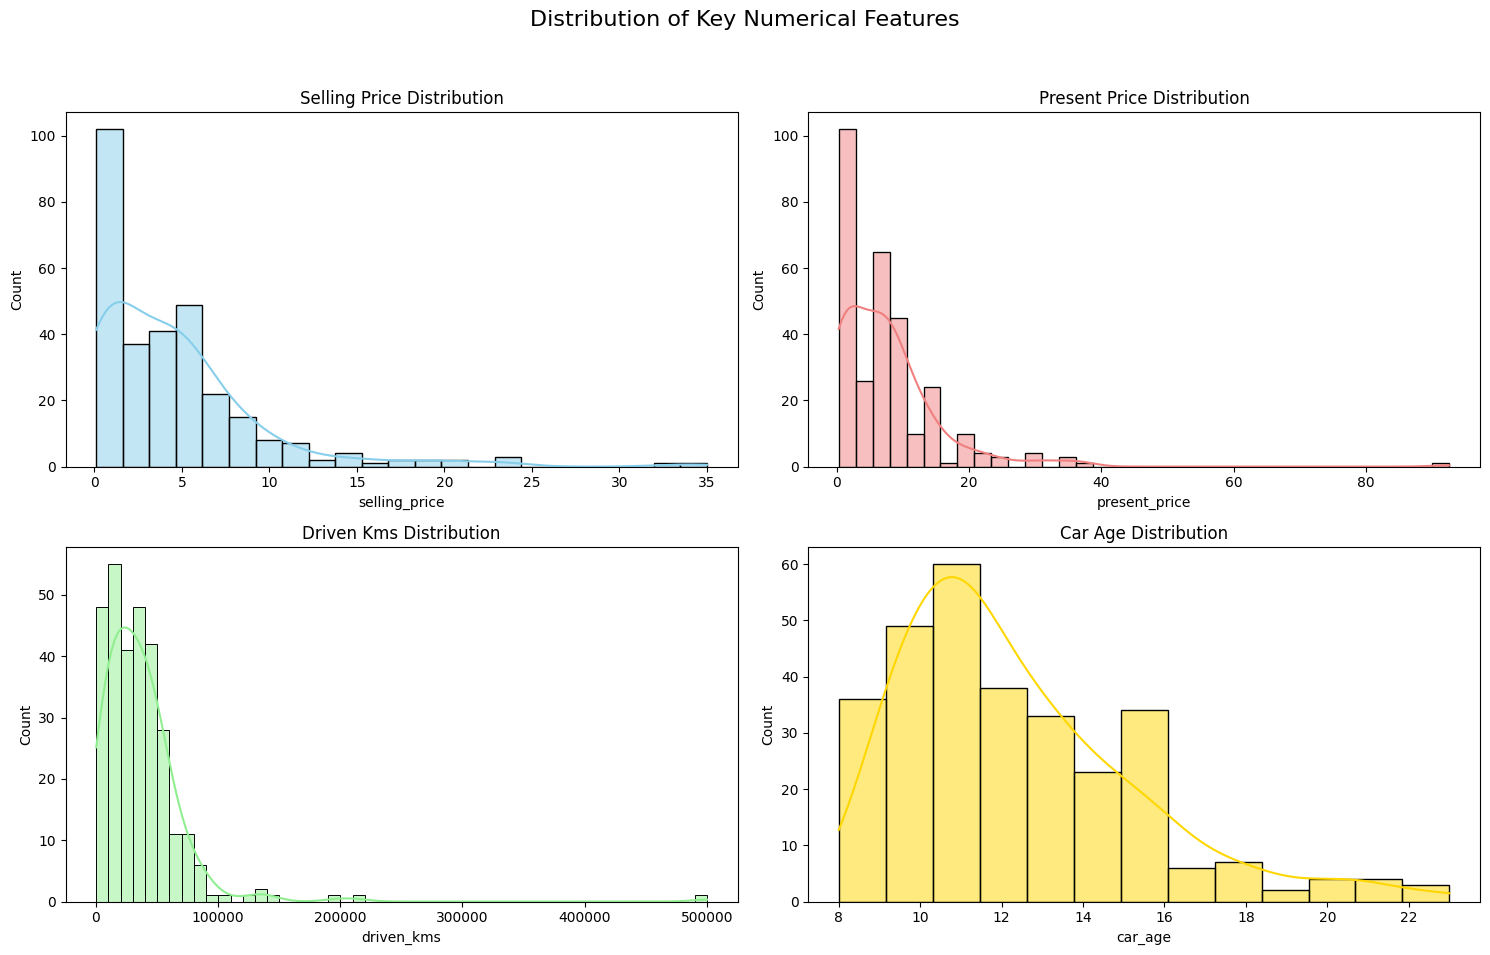

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of key numerical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16)

sns.histplot(df['selling_price'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Selling Price Distribution')

sns.histplot(df['present_price'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Present Price Distribution')

sns.histplot(df['driven_kms'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Driven Kms Distribution')

sns.histplot(df['car_age'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Car Age Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

These histograms and KDE plots visualize the distribution of `selling_price`, `present_price`, `driven_kms`, and `car_age`. They help to understand the spread, central tendency, and skewness of these important variables.

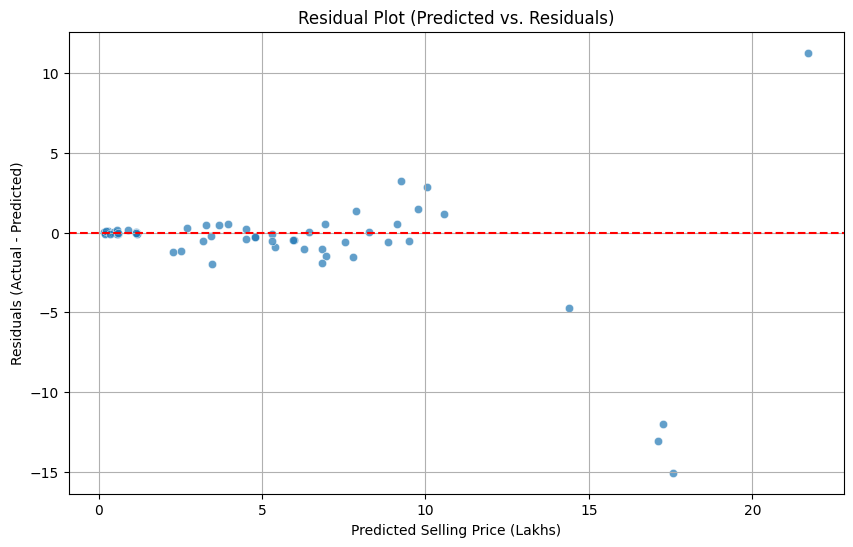

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Selling Price (Lakhs)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Predicted vs. Residuals)')
plt.grid(True)
plt.show()

The residual plot shows the difference between the actual and predicted values. Ideally, residuals should be randomly scattered around zero, indicating that the model captures the underlying patterns well. Any discernible pattern (e.g., a curve, a funnel shape) might suggest that the model has biases or that certain assumptions are violated.

understanding realworld applications of machine learning in price prediction
Machine learning is incredibly powerful for price prediction across various industries. Here are some real-world applications:

E-commerce and Retail: Predicting product prices based on demand, seasonality, competitor pricing, and historical sales data. This helps in dynamic pricing strategies, inventory management, and maximizing revenue.

Real Estate: Estimating property values based on features like location, size, number of bedrooms, recent sales in the area, market trends, and economic indicators. This is crucial for buyers, sellers, and real estate agents.

Stock Market and Finance: Predicting stock prices, commodity prices, and currency exchange rates. While challenging, ML models can identify patterns and correlations in vast amounts of financial data to inform trading decisions.

Automotive Industry: Predicting the resale value of cars, which is what we've been working on! This is useful for dealerships, insurance companies, and consumers.

Travel and Hospitality: Dynamic pricing for flights, hotel rooms, and rental cars, adjusting prices based on booking patterns, seasonality, events, and competitor pricing.

Energy Sector: Predicting electricity prices or fuel prices based on supply and demand, weather forecasts, geopolitical events, and economic conditions.

Advertising: Predicting the optimal bid price for ad space to maximize ROI for advertisers.

.Key advantages of using machine learning for price prediction include the ability to handle complex, non-linear relationships between features, adapt to changing market conditions, and process large datasets efficiently. The more data and relevant features you have, the more accurate these models tend to be.